In [1]:
!python -m pip install medmnist


In [2]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install tensorflow

In [3]:
import os
import numpy as np

dataset_dir = r"D:\Projet ML\DATA\ChestMNIST"

npz_files = [f for f in os.listdir(dataset_dir) if f.endswith(".npz")]
npz_files.sort()

print("Fichiers trouvés :")
for f in npz_files:
    full_path = os.path.join(dataset_dir, f)
    size_gb = os.path.getsize(full_path) / (1024**3)
    print(f"- {f} | {size_gb:.2f} Go")

print("\n--- Inspection d'un fichier ---")
sample_file = os.path.join(dataset_dir, npz_files[0])
print("Fichier inspecté :", sample_file)

data = np.load(sample_file)

print("\nClés contenues dans le fichier :")
for key in data.files:
    arr = data[key]
    print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")

Fichiers trouvés :
- chestmnist.npz | 0.08 Go
- chestmnist_128.npz | 1.33 Go
- chestmnist_224.npz | 3.62 Go
- chestmnist_64.npz | 0.37 Go

--- Inspection d'un fichier ---
Fichier inspecté : D:\Projet ML\DATA\ChestMNIST\chestmnist.npz

Clés contenues dans le fichier :
train_images: shape=(78468, 28, 28), dtype=uint8
val_images: shape=(11219, 28, 28), dtype=uint8
test_images: shape=(22433, 28, 28), dtype=uint8
train_labels: shape=(78468, 14), dtype=uint8
val_labels: shape=(11219, 14), dtype=uint8
test_labels: shape=(22433, 14), dtype=uint8



Dans ce projet, le jeu de données principal utilisé pour la classification supervisée est **ChestMNIST**, un sous-ensemble du projet **MedMNIST**, dédié aux radiographies thoraciques. Le dataset est fourni sous forme de fichiers `.npz` contenant directement les images et les labels déjà séparés en ensembles d’apprentissage, de validation et de test.

L’inspection initiale du dossier de données montre la présence de plusieurs versions du dataset selon la résolution des images :

- `chestmnist.npz` : images en **28 × 28**
- `chestmnist_64.npz` : images en **64 × 64**
- `chestmnist_128.npz` : images en **128 × 128**
- `chestmnist_224.npz` : images en **224 × 224**

Cette disponibilité en plusieurs résolutions est intéressante dans le cadre du projet, car elle permet d’adapter les expériences au coût de calcul et aux architectures utilisées. Les modèles simples pourront être entraînés sur des tailles réduites, tandis que les architectures plus avancées, comme les modèles pré-entraînés ou les Vision Transformers, pourront exploiter des résolutions plus élevées.

L’inspection du fichier `chestmnist.npz` montre la structure suivante :

- `train_images` : `(78468, 28, 28)`
- `val_images` : `(11219, 28, 28)`
- `test_images` : `(22433, 28, 28)`
- `train_labels` : `(78468, 14)`
- `val_labels` : `(11219, 14)`
- `test_labels` : `(22433, 14)`

Les images sont stockées en type `uint8`, ce qui indique qu’elles sont codées sous forme de niveaux de gris bruts. Les labels ont une dimension `(n, 14)`, ce qui montre que la tâche n’est pas une classification mono-classe classique, mais une **classification multilabel** : une même radiographie peut être associée à plusieurs pathologies simultanément.

La présence d’une séparation explicite entre apprentissage, validation et test constitue un point important pour garantir une évaluation rigoureuse et limiter les risques de fuite de données dans la suite du projet.

In [4]:
import numpy as np
import pandas as pd



dataset_path = r"D:\Projet ML\DATA\ChestMNIST\chestmnist_128.npz"
data = np.load(dataset_path)

X_train = data["train_images"]
X_val = data["val_images"]
X_test = data["test_images"]

y_train = data["train_labels"]
y_val = data["val_labels"]
y_test = data["test_labels"]

print("=== Shapes initiales ===")
print("X_train :", X_train.shape, X_train.dtype)
print("X_val   :", X_val.shape, X_val.dtype)
print("X_test  :", X_test.shape, X_test.dtype)
print("y_train :", y_train.shape, y_train.dtype)
print("y_val   :", y_val.shape, y_val.dtype)
print("y_test  :", y_test.shape, y_test.dtype)


# canal pour CNN / DL

X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print("\n=== Shapes après ajout du canal ===")
print("X_train :", X_train.shape)
print("X_val   :", X_val.shape)
print("X_test  :", X_test.shape)


# Normalisation des images

X_train = X_train.astype(np.float32) / 255.0
X_val = X_val.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print("\n=== Vérification normalisation ===")
print("X_train dtype :", X_train.dtype)
print("Min train :", X_train.min(), "| Max train :", X_train.max())
print("Min val   :", X_val.min(), "| Max val   :", X_val.max())
print("Min test  :", X_test.min(), "| Max test  :", X_test.max())


# Conversion des labels pour entraînement multilabel

y_train = y_train.astype(np.float32)
y_val = y_val.astype(np.float32)
y_test = y_test.astype(np.float32)

print("\n=== Vérification labels ===")
print("y_train dtype :", y_train.dtype)
print("Valeurs uniques dans y_train :", np.unique(y_train))



from medmnist import INFO

info = INFO["chestmnist"]

if isinstance(info["label"], dict):
    label_names = [info["label"][str(i)] if str(i) in info["label"] else info["label"][i] for i in range(len(info["label"]))]
else:
    label_names = list(info["label"])

print("\n=== Labels ===")
for i, name in enumerate(label_names):
    print(i, ":", name)


# Fréquence chaque classe

positive_counts = y_train.sum(axis=0)
negative_counts = len(y_train) - positive_counts

df_class_stats = pd.DataFrame({
    "label": label_names,
    "positive_count": positive_counts.astype(int),
    "negative_count": negative_counts.astype(int),
    "positive_ratio": positive_counts / len(y_train),
    "negative_ratio": negative_counts / len(y_train)
})

print("\n=== Statistiques des classes ===")
print(df_class_stats.sort_values("positive_count", ascending=False).to_string(index=False))


#Poids de classes simples pour BCE pondérée

pos_weight = negative_counts / np.maximum(positive_counts, 1)

df_weights = pd.DataFrame({
    "label": label_names,
    "pos_weight": pos_weight
}).sort_values("pos_weight", ascending=False)

print("\n=== Poids de classes (pos_weight) ===")
print(df_weights.to_string(index=False))

print("\n=== Résumé ===")
print("Shape finale X_train :", X_train.shape)
print("Shape finale y_train :", y_train.shape)

=== Shapes initiales ===
X_train : (78468, 128, 128) uint8
X_val   : (11219, 128, 128) uint8
X_test  : (22433, 128, 128) uint8
y_train : (78468, 14) uint8
y_val   : (11219, 14) uint8
y_test  : (22433, 14) uint8

=== Shapes après ajout du canal ===
X_train : (78468, 128, 128, 1)
X_val   : (11219, 128, 128, 1)
X_test  : (22433, 128, 128, 1)

=== Vérification normalisation ===
X_train dtype : float32
Min train : 0.0 | Max train : 1.0
Min val   : 0.0 | Max val   : 1.0
Min test  : 0.0 | Max test  : 1.0

=== Vérification labels ===
y_train dtype : float32
Valeurs uniques dans y_train : [0. 1.]

=== Labels ===
0 : atelectasis
1 : cardiomegaly
2 : effusion
3 : infiltration
4 : mass
5 : nodule
6 : pneumonia
7 : pneumothorax
8 : consolidation
9 : edema
10 : emphysema
11 : fibrosis
12 : pleural
13 : hernia

=== Statistiques des classes ===
        label  positive_count  negative_count  positive_ratio  negative_ratio
 infiltration           13914           64554        0.177321        0.822679
   

## Interprétation des premières étapes de préparation des données

Cette première phase de préparation des données avait pour objectif de transformer les radiographies brutes de **ChestMNIST_128** en un format directement exploitable par des modèles de deep learning.

### 1. Vérification des formes initiales

Les données chargées confirment la structure attendue du dataset :

- `X_train` : **(78468, 128, 128)**
- `X_val` : **(11219, 128, 128)**
- `X_test` : **(22433, 128, 128)**

Les labels sont de forme :

- `y_train` : **(78468, 14)**
- `y_val` : **(11219, 14)**
- `y_test` : **(22433, 14)**

Ces résultats montrent que chaque image est stockée initialement sous forme de matrice 2D en niveaux de gris, et que chaque observation possède un vecteur binaire de longueur 14 correspondant aux pathologies possibles. La structure multilabel observée lors de l’EDA est donc bien confirmée ici.

### 2. Ajout du canal image

Les images ont ensuite été transformées de la forme `(N, H, W)` vers `(N, H, W, 1)`. Cette étape est importante, car les architectures de deep learning en vision attendent généralement une dimension de canal explicite, même dans le cas d’images en niveaux de gris.

Après cette transformation, les shapes deviennent :

- `X_train` : **(78468, 128, 128, 1)**
- `X_val` : **(11219, 128, 128, 1)**
- `X_test` : **(22433, 128, 128, 1)**

Cette étape rend les tenseurs compatibles avec un pipeline CNN standard.

### 3. Normalisation des images

Les images, initialement codées en `uint8` avec des intensités entre 0 et 255, ont été converties en `float32` puis normalisées dans l’intervalle **[0, 1]**. Les résultats affichés montrent bien :

- minimum train : **0.0**
- maximum train : **1.0**
- minimum validation : **0.0**
- maximum validation : **1.0**
- minimum test : **0.0**
- maximum test : **1.0**

Cette normalisation est une étape classique mais essentielle. Elle permet de stabiliser l’apprentissage des réseaux de neurones, de rendre les gradients plus contrôlables, et d’éviter des écarts d’échelle inutiles entre les entrées.

### 4. Préparation des labels

Les labels ont été convertis en `float32`, avec des valeurs uniques égales à **0.0** et **1.0**. Cela est cohérent avec une tâche de classification multilabel, dans laquelle chaque sortie du modèle devra estimer indépendamment la probabilité de présence d’une pathologie.

Cette préparation sera utile pour utiliser plus tard une fonction de perte adaptée, comme une **binary cross-entropy** appliquée indépendamment à chaque label.

### 5. Résultat de cette étape

À l’issue de cette première préparation, les données sont désormais dans un format adapté à l’entraînement :

- les images ont une dimension de canal explicite ;
- les intensités sont normalisées ;
- les labels sont binaires et dans un type numérique compatible avec l’apprentissage profond.

Cette étape constitue la base technique du pipeline. La suite devra maintenant traiter deux éléments essentiels du sujet :

1. la **gestion du déséquilibre des classes** ;
2. la **mise en place d’une stratégie d’augmentation de données** sans créer de fuite d’information entre train, validation et test.

=== Statistiques détaillées des classes ===
        label  positive_count  negative_count  positive_ratio  negative_ratio  pos_weight
 infiltration           13914           64554        0.177321        0.822679    4.639500
     effusion            9261           69207        0.118023        0.881977    7.472951
  atelectasis            7996           70472        0.101901        0.898099    8.813407
       nodule            4375           74093        0.055755        0.944245   16.935543
         mass            3988           74480        0.050823        0.949177   18.676027
 pneumothorax            3705           74763        0.047217        0.952783   20.178947
consolidation            3263           75205        0.041584        0.958416   23.047810
      pleural            2279           76189        0.029044        0.970956   33.430889
 cardiomegaly            1950           76518        0.024851        0.975149   39.240002
    emphysema            1799           76669        0.0

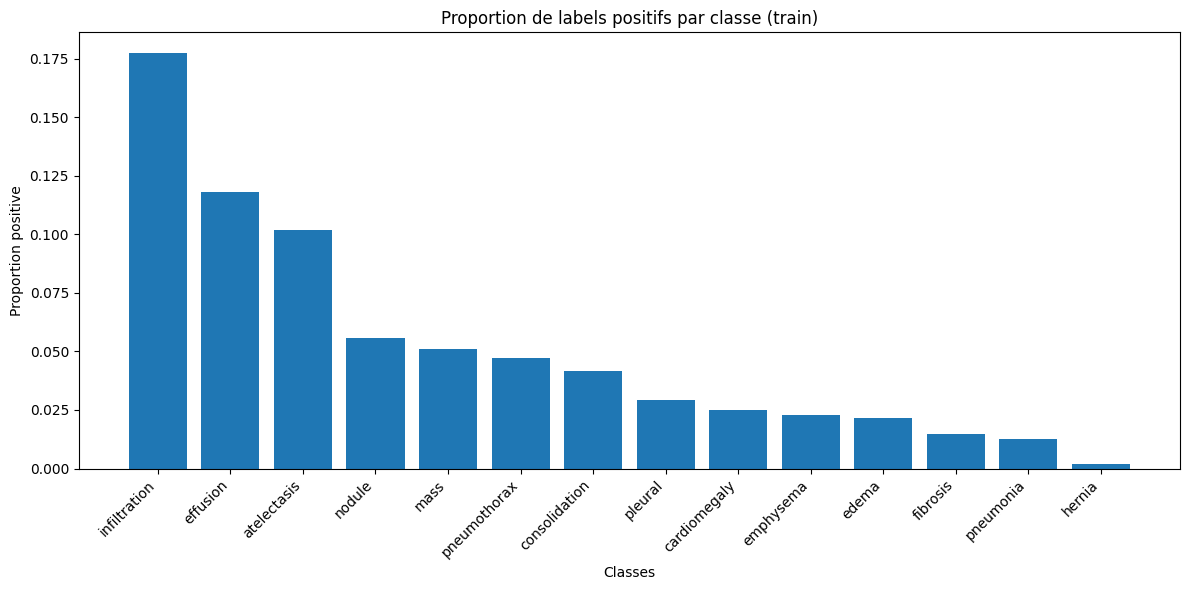

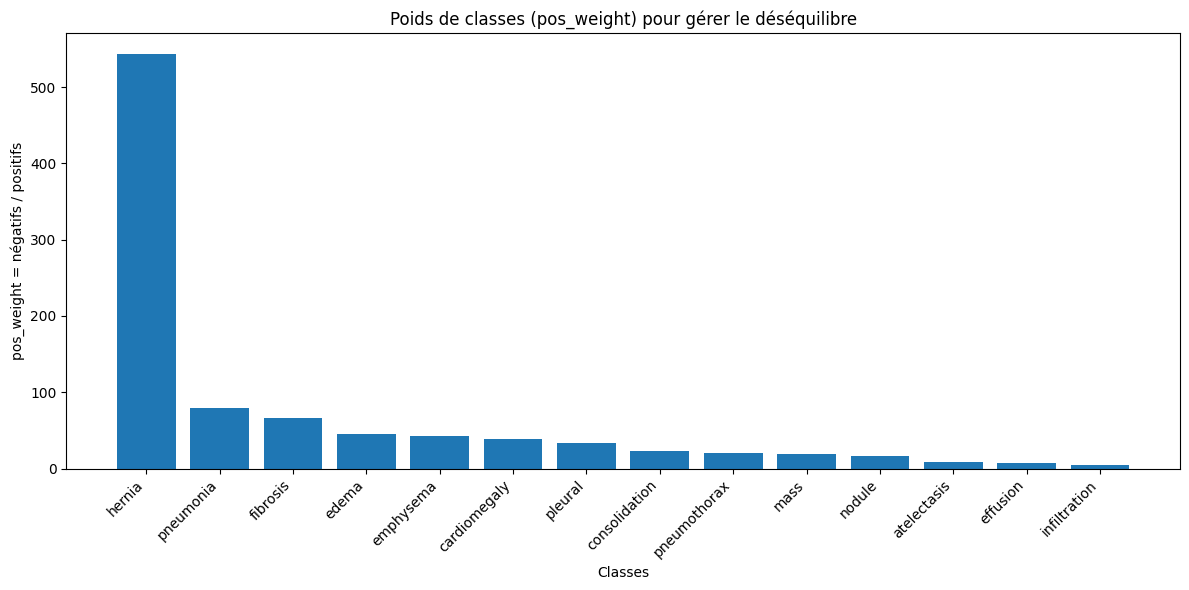


=== Pipeline d'augmentation défini ===
<Sequential name=data_augmentation, built=False>


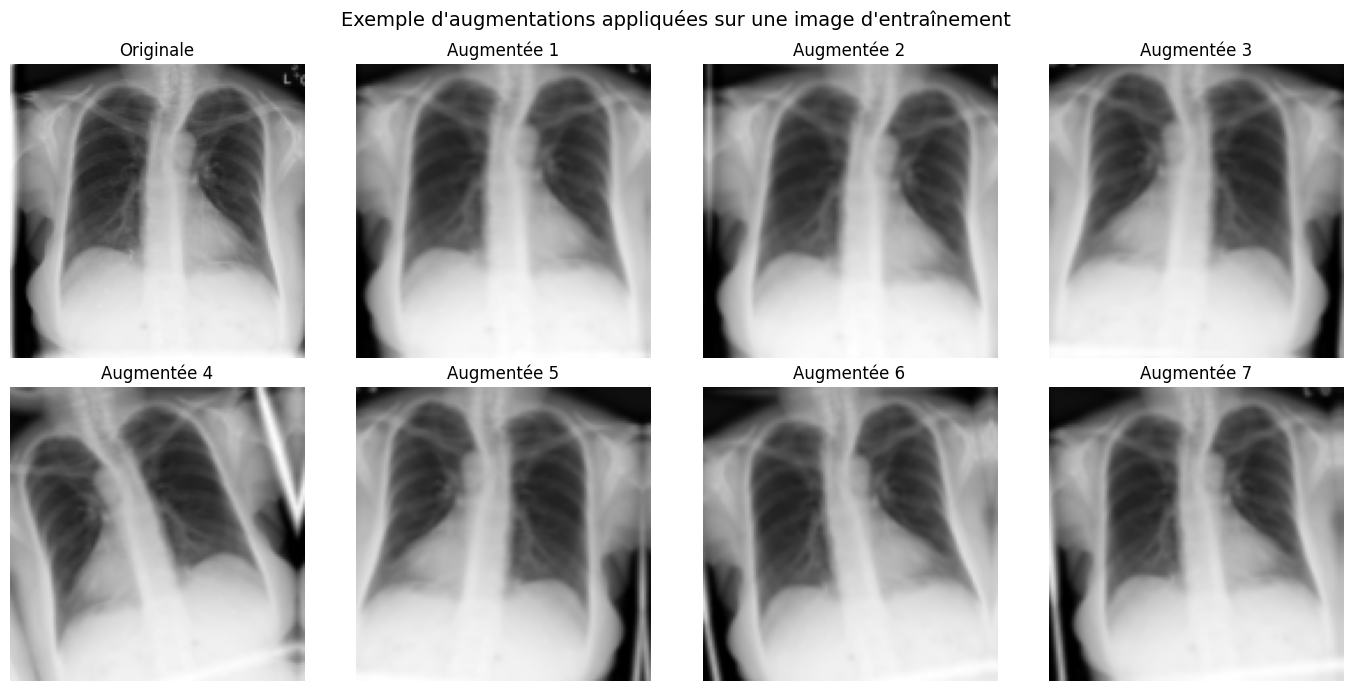


=== Vérification anti-fuite ===
Train set utilisé pour augmentation : (78468, 128, 128, 1)
Validation set laissé intact        : (11219, 128, 128, 1)
Test set laissé intact              : (22433, 128, 128, 1)
=> Aucune augmentation ne doit être appliquée sur val/test.

=== Résumé preprocessing ===
image_shape: (128, 128, 1)
normalization: [0,1]
label_format: multilabel float32
augmentation_train_only: True
val_test_untouched: True


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


# Statistiques détaillées des classes

positive_counts = y_train.sum(axis=0)
negative_counts = len(y_train) - positive_counts
pos_weight = negative_counts / np.maximum(positive_counts, 1)

df_class_stats = pd.DataFrame({
    "label": label_names,
    "positive_count": positive_counts.astype(int),
    "negative_count": negative_counts.astype(int),
    "positive_ratio": positive_counts / len(y_train),
    "negative_ratio": negative_counts / len(y_train),
    "pos_weight": pos_weight
}).sort_values("positive_count", ascending=False)

print("=== Statistiques détaillées des classes ===")
print(df_class_stats.to_string(index=False))

# Visualisation des positive_ratio

plt.figure(figsize=(12, 6))
plt.bar(df_class_stats["label"], df_class_stats["positive_ratio"])
plt.xticks(rotation=45, ha="right")
plt.title("Proportion de labels positifs par classe (train)")
plt.xlabel("Classes")
plt.ylabel("Proportion positive")
plt.tight_layout()
plt.show()


df_weights_sorted = df_class_stats.sort_values("pos_weight", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(df_weights_sorted["label"], df_weights_sorted["pos_weight"])
plt.xticks(rotation=45, ha="right")
plt.title("Poids de classes (pos_weight) pour gérer le déséquilibre")
plt.xlabel("Classes")
plt.ylabel("pos_weight = négatifs / positifs")
plt.tight_layout()
plt.show()


# data augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomTranslation(height_factor=0.03, width_factor=0.03),
], name="data_augmentation")

print("\n=== Pipeline d'augmentation défini ===")
print(data_augmentation)


# Vérification visuelle de l’augmentation

sample_idx = 0
sample_image = X_train[sample_idx:sample_idx+1]  # shape (1, 128, 128, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Exemple d'augmentations appliquées sur une image d'entraînement", fontsize=14)

axes[0, 0].imshow(sample_image[0].squeeze(), cmap="gray")
axes[0, 0].set_title("Originale")
axes[0, 0].axis("off")

for i in range(1, 8):
    aug_image = data_augmentation(sample_image, training=True)
    ax = axes.ravel()[i]
    ax.imshow(aug_image[0].numpy().squeeze(), cmap="gray")
    ax.set_title(f"Augmentée {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()


# Vérification anti-fuite de données

print("\n=== Vérification anti-fuite ===")
print("Train set utilisé pour augmentation :", X_train.shape)
print("Validation set laissé intact        :", X_val.shape)
print("Test set laissé intact              :", X_test.shape)
print("=> Aucune augmentation ne doit être appliquée sur val/test.")



preprocessing_summary = {
    "image_shape": X_train.shape[1:],
    "normalization": "[0,1]",
    "label_format": "multilabel float32",
    "augmentation_train_only": True,
    "val_test_untouched": True
}

print("\n=== Résumé preprocessing ===")
for k, v in preprocessing_summary.items():
    print(f"{k}: {v}")



### 1. Déséquilibre des classes

Les statistiques détaillées confirment que le dataset est fortement déséquilibré. La classe la plus fréquente est `infiltration`, présente dans **17,73 %** des images d’entraînement, tandis que la classe la plus rare est `hernia`, présente dans seulement **0,18 %** des cas.

Les poids calculés avec la formule `pos_weight = négatifs / positifs` montrent bien l’ampleur de ce déséquilibre. Par exemple :

- `infiltration` : **4,64**
- `effusion` : **7,47**
- `atelectasis` : **8,81**
- `pneumonia` : **79,23**
- `hernia` : **543,92**

Cela signifie qu’une erreur sur une classe rare devra être davantage pénalisée qu’une erreur sur une classe fréquente. Ce résultat justifie l’utilisation future d’une fonction de perte pondérée pour limiter le biais du modèle vers les pathologies majoritaires.

### 2. Augmentation de données

Un pipeline d’augmentation a été défini uniquement pour le jeu d’entraînement. Les transformations choisies restent modérées :

- symétrie horizontale,
- légère rotation,
- léger zoom,
- légère translation.

Les images générées montrent que les radiographies augmentées restent visuellement proches de l’originale, tout en introduisant une variabilité utile pour améliorer la robustesse du modèle. Cette précaution est importante dans un contexte médical, car des transformations trop agressives pourraient altérer l’information clinique pertinente.

### 3. Anti-fuite de données

La vérification finale confirme que l’augmentation ne sera appliquée que sur l’ensemble d’entraînement. Les ensembles de validation et de test restent inchangés. C’est un point fondamental pour garantir une évaluation honnête des modèles et respecter les bonnes pratiques imposées par le sujet.

### 4. Bilan de la préparation à ce stade

À ce stade, les données sont correctement préparées pour l’entraînement :

- format image adapté au deep learning ;
- normalisation en `[0,1]` ;
- labels multilabel en `float32` ;
- déséquilibre quantifié ;
- augmentation définie uniquement sur le train ;
- validation et test laissés intacts.


In [6]:
import tensorflow as tf

batch_size = 32
seed = 42

# Dataset train
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train), seed=seed, reshuffle_each_iteration=True)

def train_preprocess(image, label):
    image = data_augmentation(image, training=True)
    return image, label

train_ds = train_ds.map(train_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Dataset val
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("Train dataset :", train_ds)
print("Val dataset   :", val_ds)
print("Test dataset  :", test_ds)

for batch_images, batch_labels in train_ds.take(1):
    print("\n=== Batch train ===")
    print("Images shape :", batch_images.shape)
    print("Labels shape :", batch_labels.shape)
    print("Images dtype :", batch_images.dtype)
    print("Labels dtype :", batch_labels.dtype)
    print("Min pixel    :", tf.reduce_min(batch_images).numpy())
    print("Max pixel    :", tf.reduce_max(batch_images).numpy())
    print("Exemple label :", batch_labels[0].numpy())

Train dataset : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 1, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>
Val dataset   : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>
Test dataset  : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>

=== Batch train ===
Images shape : (32, 128, 128, 1, 1)
Labels shape : (32, 14)
Images dtype : <dtype: 'float32'>
Labels dtype : <dtype: 'float32'>
Min pixel    : 0.0
Max pixel    : 1.0
Exemple label : [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0.]



La création des datasets TensorFlow montre que les jeux de validation et de test ont bien la forme attendue `(None, 128, 128, 1)`. En revanche, le jeu d’entraînement présente une anomalie : les images ont la forme `(None, 128, 128, 1, 1)`, ce qui indique l’apparition d’une dimension supplémentaire non désirée.



In [7]:

batch_size = 32
seed = 42

# Dataset train
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train), seed=seed, reshuffle_each_iteration=True)

def train_preprocess(image, label):
    image = tf.ensure_shape(image, (128, 128, 1))
    image = data_augmentation(image, training=True)
    image = tf.reshape(image, (128, 128, 1))
    return image, label

train_ds = train_ds.map(train_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Dataset val
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Dataset test
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("Train dataset :", train_ds)
print("Val dataset   :", val_ds)
print("Test dataset  :", test_ds)

for batch_images, batch_labels in train_ds.take(1):
    print("\n=== Batch train ===")
    print("Images shape :", batch_images.shape)
    print("Labels shape :", batch_labels.shape)
    print("Images dtype :", batch_images.dtype)
    print("Labels dtype :", batch_labels.dtype)
    print("Min pixel    :", tf.reduce_min(batch_images).numpy())
    print("Max pixel    :", tf.reduce_max(batch_images).numpy())
    print("Exemple label :", batch_labels[0].numpy())

Train dataset : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>
Val dataset   : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>
Test dataset  : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>

=== Batch train ===
Images shape : (32, 128, 128, 1)
Labels shape : (32, 14)
Images dtype : <dtype: 'float32'>
Labels dtype : <dtype: 'float32'>
Min pixel    : 0.0
Max pixel    : 1.0
Exemple label : [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0.]


## Validation finale du pipeline de préparation

La vérification finale du pipeline TensorFlow montre que les trois jeux de données ont désormais une structure cohérente :

- train : `(None, 128, 128, 1)`
- validation : `(None, 128, 128, 1)`
- test : `(None, 128, 128, 1)`

Les labels ont tous la forme `(None, 14)`, ce qui correspond bien à une tâche multilabel avec 14 pathologies. Les types sont également corrects :

- images en `float32`
- labels en `float32`

Les intensités des images restent comprises entre **0.0** et **1.0**, ce qui confirme que la normalisation est bien conservée après l’intégration dans le pipeline `tf.data`.

Cette validation est importante, car elle garantit que :

- le format des données est compatible avec les modèles convolutifs ;
- l’ensemble d’entraînement, de validation et de test suit la même structure ;
- l’augmentation est appliquée uniquement sur le train sans modifier la représentation attendue des images.

À ce stade, le pipeline de préparation des données peut être considéré comme prêt pour l’entraînement des modèles supervisés.

In [8]:
from tensorflow.keras import layers, models

# CNN simple
cnn_scratch = models.Sequential([
    layers.Input(shape=(128, 128, 1)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(14, activation="sigmoid")
], name="cnn_scratch_chestmnist")

cnn_scratch.summary()

# Compilation
cnn_scratch.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
        tf.keras.metrics.AUC(name="auc_multi", multi_label=True, num_labels=14)
    ]
)

Model: "cnn_scratch_chestmnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,585,998 (17.49 MB)

 Trainable params: 4,585,998 (17.49 MB)

 Non-trainable params: 0 (0.00 B)